# Optuna Hyperparameter Optimization

**Optuna** is an **automatic hyperparameter optimization framework** that helps us find the best hyperparameter values for machine learning models.

Instead of manually trying different parameter combinations, Optuna intelligently searches the hyperparameter space and learns from previous trials to find better configurations faster.

Unlike **Grid Search** and **Random Search**, Optuna uses **Bayesian Optimization (Tree-structured Parzen Estimator - TPE)**, making it much more efficient.

---

# 1. Why Do We Need Optuna?

Training a machine learning model involves selecting the right hyperparameters.

Examples include:

- Learning Rate
- Number of Trees
- Maximum Tree Depth
- Regularization Parameters
- Batch Size
- Number of Epochs

Choosing these manually is difficult because there are thousands of possible combinations.

Optuna automates this process.

---

# 2. Traditional Hyperparameter Tuning Methods

Before Optuna, the two most common methods were:

- Grid Search
- Random Search

Although useful, both have limitations.

---

# A. Grid Search

Grid Search tries **every possible combination** of hyperparameters.

Suppose we have:

```
n_estimators = 5 values

max_depth = 5 values

learning_rate = 4 values
```

Grid Search trains

```
5 × 5 × 4 = 100 models
```

If another parameter with 5 values is added,

```
100 × 5 = 500 models
```

The number of combinations grows rapidly.

### Advantages

- Very simple
- Finds the best combination among the predefined values

### Limitations

- Extremely slow
- Computationally expensive
- Wastes time evaluating poor parameter combinations

---

# B. Random Search

Instead of trying every combination,

Random Search randomly selects parameter combinations.

Example

Instead of evaluating

```
500 combinations
```

it may evaluate only

```
50 random combinations
```

### Advantages

- Faster than Grid Search
- Can explore larger search spaces

### Limitations

Every trial is completely independent.

The algorithm does **not learn** from previous trials.

If one trial performs poorly,

future trials may still choose very similar parameter values.

---

# 3. Optuna

Optuna solves the problems of both Grid Search and Random Search.

Instead of blindly searching,

it learns from previous trials and intelligently explores better regions of the search space.

By default, Optuna uses

```
Tree-structured Parzen Estimator (TPE)
```

which is a Bayesian Optimization algorithm.

---

# 4. How Optuna Works

The optimization process follows a simple workflow.

```
Start

↓

Create Study

↓

Run Trial

↓

Train Model

↓

Evaluate Performance

↓

Store Result

↓

Learn from Previous Trials

↓

Generate Better Parameters

↓

Repeat
```

Instead of randomly searching,

each new trial is influenced by the results of previous trials.

---

# 5. Tree-structured Parzen Estimator (TPE)

TPE is Optuna's default optimization algorithm.

Instead of treating every trial independently,

it separates previous trials into two groups.

```
Previous Trials

        │

 ┌──────┴──────┐

Good Trials   Bad Trials
```

Then,

it learns

- which parameter values usually produce good results
- which parameter values usually produce poor results

The next trial is sampled closer to the good-performing region.

This allows Optuna to gradually improve the search.

---

# 6. Core Components of Optuna

Optuna mainly consists of three components.

- Objective Function
- Trial Object
- Study Object

---

# A. Objective Function

The Objective Function contains the complete machine learning workflow.

Typically it performs:

- Receive hyperparameters
- Train the model
- Predict
- Evaluate
- Return a score

Example workflow

```
Objective Function

↓

Sample Hyperparameters

↓

Train Model

↓

Evaluate

↓

Return Accuracy
```

The returned score becomes the optimization target.

---

# B. Trial Object

Every execution of the objective function is called a **Trial**.

The Trial object is responsible for generating hyperparameter values.

Common methods include

### Integer Parameters

```
trial.suggest_int()
```

Used for

- Number of Trees
- Maximum Depth
- Number of Neighbors

---

### Float Parameters

```
trial.suggest_float()
```

Used for

- Learning Rate
- Regularization
- Dropout Rate

It also supports

```
log=True
```

which samples values on a logarithmic scale.

This is useful for parameters like

```
0.0001

0.001

0.01

0.1
```

instead of equally spaced numbers.

---

### Categorical Parameters

```
trial.suggest_categorical()
```

Used when parameters come from a fixed list.

Example

```
Activation Function

↓

ReLU

Tanh

Sigmoid
```

---

# C. Study Object

The Study object manages the entire optimization process.

It is responsible for

- running multiple trials
- storing results
- finding the best parameters
- tracking the best score

Example workflow

```
Create Study

↓

Run Trials

↓

Compare Results

↓

Store Best Trial

↓

Return Best Parameters
```

---

# 7. Define-by-Run Architecture

One of Optuna's biggest strengths is its

```
Define-by-Run
```

approach.

Unlike traditional frameworks,

the search space can change dynamically while the program is running.

Example

```
Choose Model

↓

XGBoost

↓

Search XGBoost Parameters


OR


Logistic Regression

↓

Search Logistic Regression Parameters
```

This allows different models to have completely different hyperparameter spaces.

---

# 8. Automatic Pruning

Training poor models for hundreds of epochs wastes time.

Optuna introduces

```
Pruning
```

which is an intelligent early stopping mechanism.

Workflow

```
Start Training

↓

Evaluate After Every Epoch

↓

Good Progress?

      │
 Yes  │  No
      │
Continue

      or

Stop Trial
```

If Optuna determines that the current trial is unlikely to outperform previous trials,

it immediately stops the training.

This saves a significant amount of computation.

---

# 9. Persistent Storage

Normally,

when the Python script finishes,

all optimization history is lost.

Optuna allows storing the study inside a database.

Example

```
SQLite

PostgreSQL

MySQL
```

Benefits

- Resume optimization later
- Save all trials
- Keep experiment history
- Share studies across machines

---

# 10. Parallel Optimization

Optuna supports parallel execution.

Multiple workers can optimize the same study simultaneously.

```
Worker 1

      │

Worker 2

      │

Worker 3

      │

──────────────

Shared Database

──────────────

      │

Best Parameters
```

This greatly reduces optimization time on multi-core CPUs or distributed systems.

---

# 11. Advantages of Optuna

- Faster than Grid Search
- Learns from previous trials
- Efficient search using Bayesian Optimization
- Automatic pruning of poor trials
- Dynamic search space
- Supports parallel execution
- Easy integration with Scikit-Learn, XGBoost, LightGBM, CatBoost, TensorFlow, and PyTorch

---

# 12. Limitations

- Slightly more complex than Grid Search
- Bayesian Optimization may require several trials before converging
- Large search spaces can still be computationally expensive

---

# 13. When Should You Use Optuna?

Use Optuna when:

- Hyperparameter tuning is important
- Training models is expensive
- Search space is large
- You want automatic optimization
- You need faster convergence than Grid Search or Random Search

Avoid Optuna when:

- Very small models are being trained
- Only a few hyperparameters need tuning
- Exhaustive Grid Search is affordable

---

# 14. Summary

| Concept | Description |
|---------|-------------|
| Learning Type | Hyperparameter Optimization Framework |
| Default Optimizer | Tree-structured Parzen Estimator (TPE) |
| Search Strategy | Bayesian Optimization |
| Core Components | Objective Function, Trial, Study |
| Parameter Types | Integer, Float, Categorical |
| Major Feature | Learns from previous trials |
| Advanced Features | Automatic Pruning, Define-by-Run, Parallel Optimization |
| Storage Support | SQLite, PostgreSQL, MySQL |
| Main Goal | Find the best hyperparameters efficiently |

---

# Overall Workflow

```text
              Define Objective Function
                        │
                        ▼
                 Create Study Object
                        │
                        ▼
                Generate Trial Parameters
                        │
                        ▼
                   Train the Model
                        │
                        ▼
                 Evaluate Performance
                        │
                        ▼
            Better than Previous Trials?
                  │                 │
                Yes                No
                  │                 │
        Update Best Parameters   Learn & Continue
                  │
                  ▼
          Generate Next Trial (TPE)
                  │
                  ▼
          Repeat Until Trials Finish
                  │
                  ▼
        Return Best Hyperparameters
```

Optuna Paper - https://arxiv.org/pdf/1907.10902  

Bayesian Optimization (TPE) Paper - https://arxiv.org/pdf/2304.11127

In [3]:
!pip install optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   -------------------------

In [4]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (537, 8)
Test set shape: (231, 8)


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)   # trial.suggest_in = Function that learns from previous steps
    max_depth = trial.suggest_int('max_depth', 3, 20) 

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [9]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-07-09 22:49:50,746] A new study created in memory with name: no-name-af338b6d-f79e-4e4f-8b5b-6aced52404af
[I 2026-07-09 22:49:52,043] Trial 0 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 84, 'max_depth': 4}. Best is trial 0 with value: 0.7616387337057727.
[I 2026-07-09 22:49:54,099] Trial 1 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 126, 'max_depth': 14}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-07-09 22:49:55,975] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 112, 'max_depth': 15}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-07-09 22:49:58,779] Trial 3 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 175, 'max_depth': 15}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-07-09 22:50:00,796] Trial 4 finished with value: 0.7783985102420856 and parameters: {'n_estimators': 123, 'max_depth': 16}. Best is trial 4 with value: 0.778398

In [10]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7783985102420857
Best hyperparameters: {'n_estimators': 72, 'max_depth': 19}


In [14]:
# Train the RF on the hyperparams given by Optuna 

from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.76


## Samplers in Optuna

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [19]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy 
# Direction = maximize -> Profit , accuracy & mininze -> Loss

study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-07-09 22:55:15,500] A new study created in memory with name: no-name-eed5832b-b463-448c-a821-6f8f8724cf4b
[I 2026-07-09 22:55:16,718] Trial 0 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 75, 'max_depth': 11}. Best is trial 0 with value: 0.7709497206703911.
[I 2026-07-09 22:55:18,121] Trial 1 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 90, 'max_depth': 10}. Best is trial 0 with value: 0.7709497206703911.
[I 2026-07-09 22:55:19,625] Trial 2 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 95, 'max_depth': 17}. Best is trial 0 with value: 0.7709497206703911.
[I 2026-07-09 22:55:20,508] Trial 3 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 54, 'max_depth': 20}. Best is trial 3 with value: 0.7746741154562384.
[I 2026-07-09 22:55:21,686] Trial 4 finished with value: 0.7765363128491621 and parameters: {'n_estimators': 77, 'max_depth': 7}. Best is trial 4 with value: 0.7765363128

In [20]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7783985102420856
Best hyperparameters: {'n_estimators': 121, 'max_depth': 17}


In [21]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


In [22]:
# using Optuna as a gridsearch 

In [23]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [24]:
# Create a study and optimize it using GridSampler
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2026-07-09 22:57:24,391] A new study created in memory with name: no-name-f13ae1cc-5d72-4df2-b6d3-73dcd1fdad58
[I 2026-07-09 22:57:25,892] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-07-09 22:57:28,325] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-07-09 22:57:29,209] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-07-09 22:57:30,815] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-07-09 22:57:32,395] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [25]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7746741154562384
Best hyperparameters: {'n_estimators': 50, 'max_depth': 5}


In [26]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


## Optuna Visualizations  

In [27]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

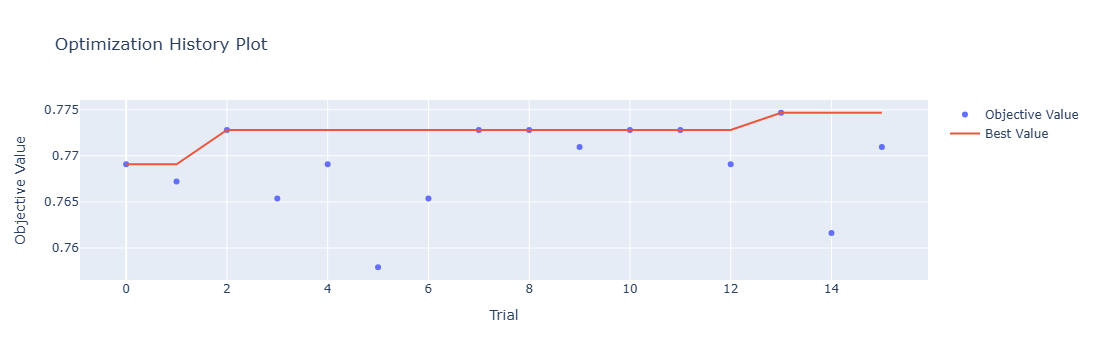

In [28]:
# 1. Optimization History
plot_optimization_history(study).show()

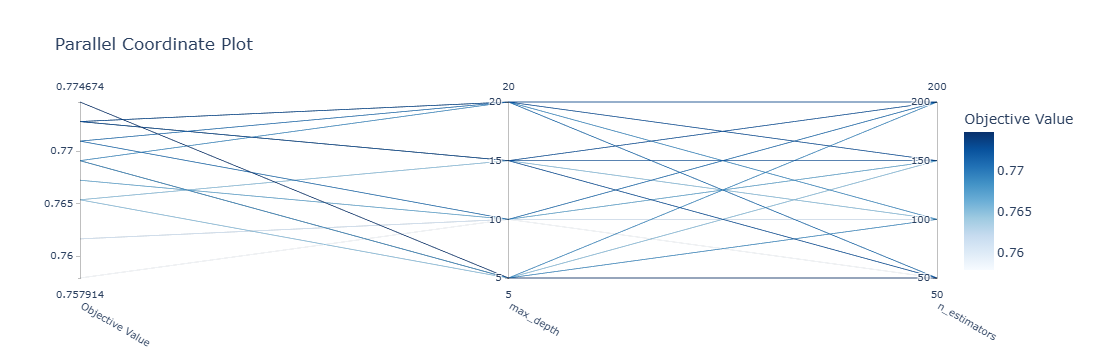

In [29]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

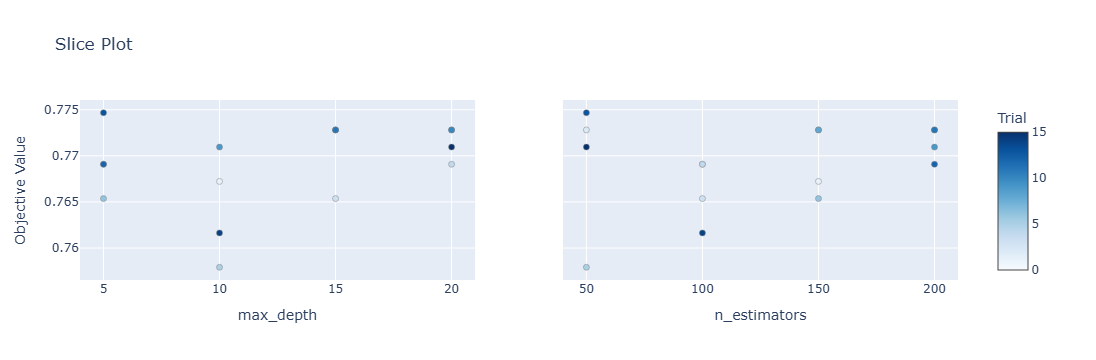

In [30]:
# 3. Slice Plot
plot_slice(study).show()

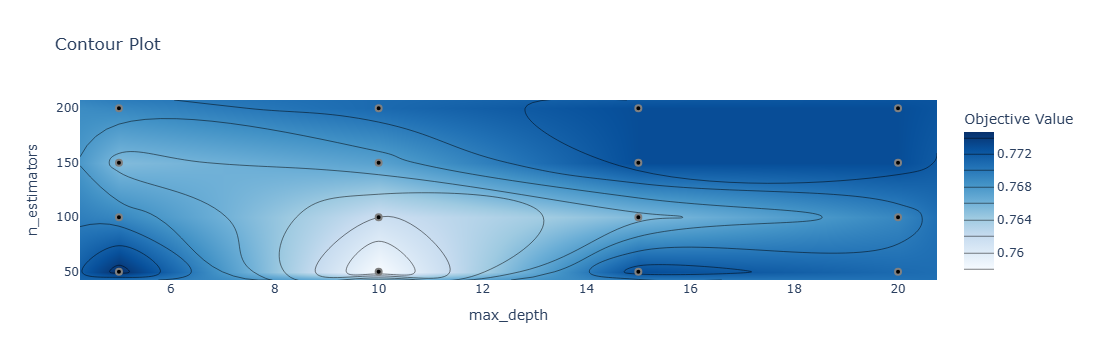

In [31]:
# 4. Contour Plot
plot_contour(study).show()

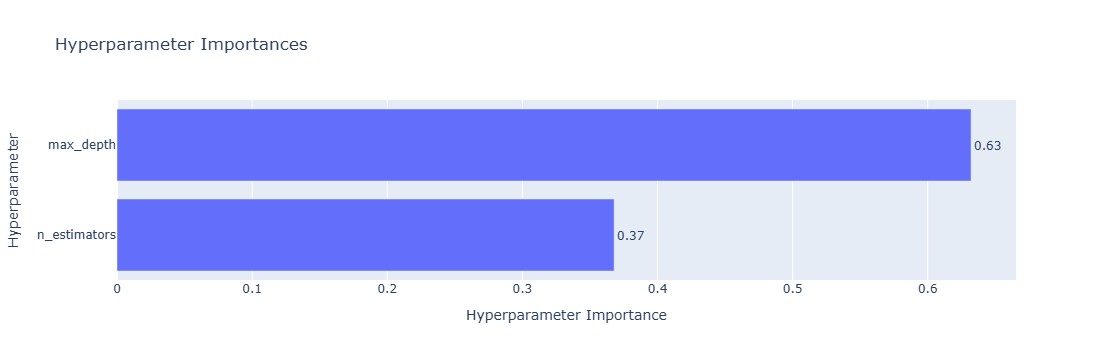

In [32]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

# One of the Best Features of Optuna is 

## Optimizing Multiple ML Models

In [35]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [36]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [37]:
# We have created same funtion but this time we are using model as an Hyperparameter and finding out the best model with its parameters

In [38]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-07-09 23:01:43,819] A new study created in memory with name: no-name-d85d9aa7-5944-4149-a4c4-7e70a16583af
[I 2026-07-09 23:01:43,937] Trial 0 finished with value: 0.7672253258845437 and parameters: {'classifier': 'SVM', 'C': 1.417825027303821, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.7672253258845437.
[I 2026-07-09 23:01:49,380] Trial 1 finished with value: 0.7299813780260708 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 211, 'learning_rate': 0.16359440603253628, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.7672253258845437.
[I 2026-07-09 23:01:49,489] Trial 2 finished with value: 0.7690875232774674 and parameters: {'classifier': 'SVM', 'C': 1.6569836819623756, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.7690875232774674.
[I 2026-07-09 23:01:51,032] Trial 3 finished with value: 0.7746741154562384 and parameters: {'classifier': 'RandomForest', 'n_estimators': 11

In [39]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'SVM', 'C': 0.12545248514493734, 'kernel': 'linear', 'gamma': 'auto'}
Best trial accuracy: 0.7895716945996275


In [40]:
# we can store these outputs in the dataframe 
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.767225,2026-07-09 23:01:43.824094,2026-07-09 23:01:43.937350,0 days 00:00:00.113256,1.417825,NaN,SVM,scale,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE
1,1,0.729981,2026-07-09 23:01:43.940188,2026-07-09 23:01:49.380174,0 days 00:00:05.439986,NaN,NaN,GradientBoosting,NaN,NaN,0.163594,8.0,10.0,10.0,211.0,COMPLETE
2,2,0.769088,2026-07-09 23:01:49.383480,2026-07-09 23:01:49.489234,0 days 00:00:00.105754,1.656984,NaN,SVM,scale,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE
3,3,0.774674,2026-07-09 23:01:49.491914,2026-07-09 23:01:51.032109,0 days 00:00:01.540195,NaN,False,RandomForest,NaN,NaN,NaN,8.0,5.0,9.0,119.0,COMPLETE
4,4,0.746741,2026-07-09 23:01:51.035375,2026-07-09 23:02:01.298219,0 days 00:00:10.262844,NaN,NaN,GradientBoosting,NaN,NaN,0.139318,19.0,3.0,6.0,139.0,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.787709,2026-07-09 23:03:34.619889,2026-07-09 23:03:34.700222,0 days 00:00:00.080333,0.169363,NaN,SVM,auto,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
96,96,0.789572,2026-07-09 23:03:34.703241,2026-07-09 23:03:34.787760,0 days 00:00:00.084519,0.141017,NaN,SVM,auto,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
97,97,0.767225,2026-07-09 23:03:34.790562,2026-07-09 23:03:34.891555,0 days 00:00:00.100993,0.218159,NaN,SVM,scale,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.707635,2026-07-09 23:03:34.894831,2026-07-09 23:03:35.029127,0 days 00:00:00.134296,0.103878,NaN,SVM,auto,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [41]:
# No of times the trail used that model 
study.trials_dataframe()['params_classifier'].value_counts()

params_classifier
SVM                 71
RandomForest        20
GradientBoosting     9
Name: count, dtype: int64

In [42]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

params_classifier
GradientBoosting    0.744879
RandomForest        0.769088
SVM                 0.777113
Name: value, dtype: float64

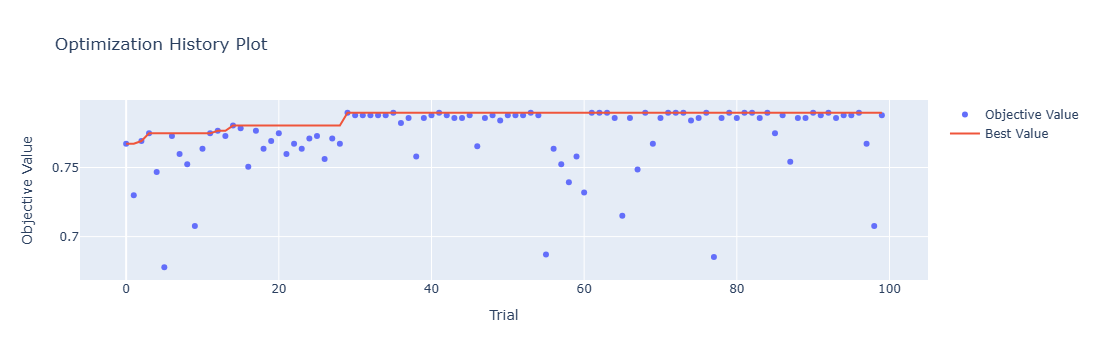

In [43]:
# 1. Optimization History
plot_optimization_history(study).show()

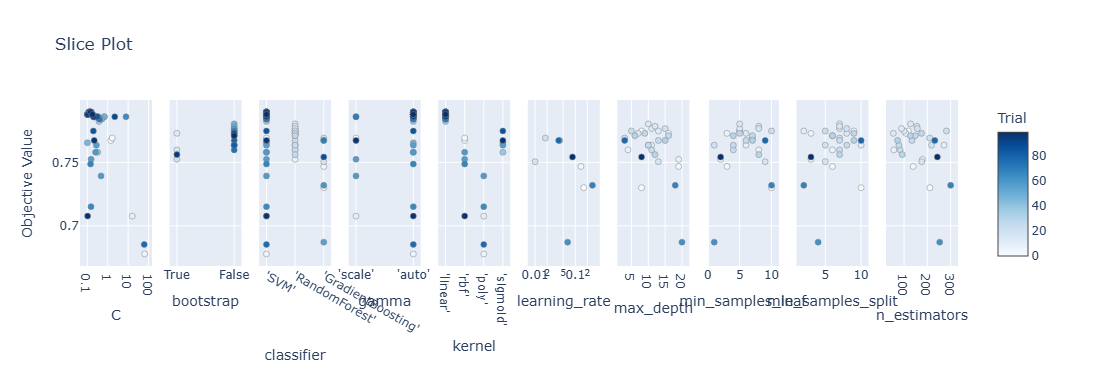

In [44]:
# 3. Slice Plot
plot_slice(study).show()

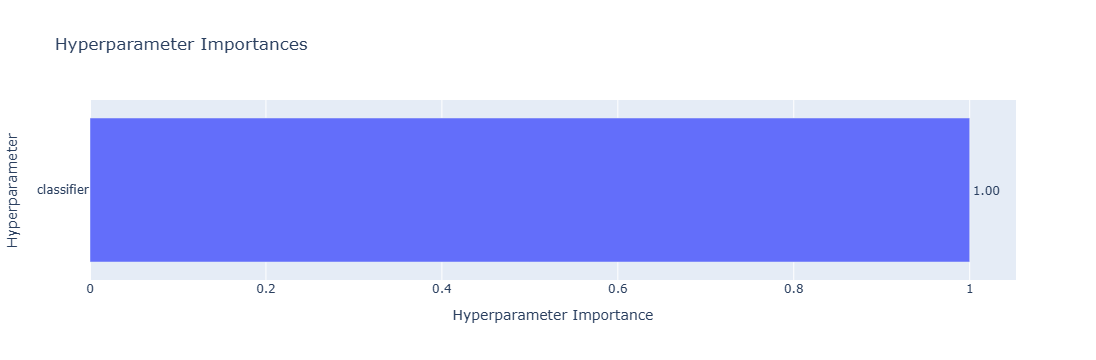

In [45]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()